In [23]:
!pip install imblearn

   ---------------------------------------- 0.0/238.4 kB ? eta -:--:--
   ------ -------------------------------- 41.0/238.4 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------  235.5/238.4 kB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 238.4/238.4 kB 2.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\student\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [8]:
print(df.columns)

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)


In [9]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Select relevant features
selected_columns = [
    "fico_range_high", "fico_range_low", "dti", "emp_length", "loan_status",
    "loan_amnt", "int_rate", "home_ownership", "annual_inc", "verification_status", "delinq_2yrs"
]

df_selected = df[selected_columns].copy()

# Display summary
print(df_selected.info())
print(df_selected.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   fico_range_high      float64
 1   fico_range_low       float64
 2   dti                  float64
 3   emp_length           object 
 4   loan_status          object 
 5   loan_amnt            float64
 6   int_rate             float64
 7   home_ownership       object 
 8   annual_inc           float64
 9   verification_status  object 
 10  delinq_2yrs          float64
dtypes: float64(7), object(4)
memory usage: 189.7+ MB
None
   fico_range_high  fico_range_low    dti emp_length loan_status  loan_amnt  \
0            679.0           675.0   5.91  10+ years  Fully Paid     3600.0   
1            719.0           715.0  16.06  10+ years  Fully Paid    24700.0   
2            699.0           695.0  10.78  10+ years  Fully Paid    20000.0   
3            789.0           785.0  17.06  10+ years     Current    35

In [11]:
print(df_selected.isnull().sum())

fico_range_high            33
fico_range_low             33
dti                      1744
emp_length             146940
loan_status                33
loan_amnt                  33
int_rate                   33
home_ownership             33
annual_inc                 37
verification_status        33
delinq_2yrs                62
dtype: int64


In [19]:
print(df_selected["loan_status"].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [20]:
# Define default vs. non-default
default_status = ["Charged Off", "Default", "Does not meet the credit policy. Status: Charged Off"]

# Create binary target variable (1 = Default, 0 = Fully Paid)
df_selected["loan_status"] = df_selected["loan_status"].apply(lambda x: 1 if x in default_status else 0)

# Check new class distribution
print(df_selected["loan_status"].value_counts())


loan_status
0    1992102
1     268599
Name: count, dtype: int64


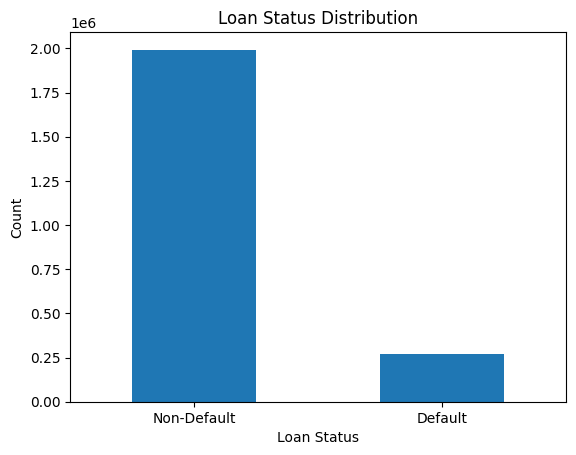

In [21]:
import matplotlib.pyplot as plt

# Plot class distribution
df_selected["loan_status"].value_counts().plot(kind="bar", title="Loan Status Distribution")
plt.xticks(ticks=[0, 1], labels=["Non-Default", "Default"], rotation=0)
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

In [25]:
print(df_selected.dtypes)

fico_range_high        float64
fico_range_low         float64
dti                    float64
emp_length              object
loan_status              int64
loan_amnt              float64
int_rate               float64
home_ownership          object
annual_inc             float64
verification_status     object
delinq_2yrs            float64
dtype: object


In [28]:
# Convert categorical variables into numerical values
df_selected = pd.get_dummies(df_selected, columns=["home_ownership", "verification_status"], drop_first=True)

# Check new column names
print(df_selected.dtypes)


fico_range_high                        float64
fico_range_low                         float64
dti                                    float64
emp_length                             float64
loan_status                              int64
loan_amnt                              float64
int_rate                               float64
annual_inc                             float64
delinq_2yrs                            float64
home_ownership_MORTGAGE                   bool
home_ownership_NONE                       bool
home_ownership_OTHER                      bool
home_ownership_OWN                        bool
home_ownership_RENT                       bool
verification_status_Source Verified       bool
verification_status_Verified              bool
dtype: object


In [30]:
print(df_selected["emp_length"].dtype)

float64


In [33]:
# Identify numerical columns
num_cols = df_selected.select_dtypes(include=["float64", "int64"]).columns

# Fill missing numerical values with median
df_selected[num_cols] = df_selected[num_cols].fillna(df_selected[num_cols].median())

# Confirm missing values are gone
print(df_selected.isnull().sum())


fico_range_high                        0
fico_range_low                         0
dti                                    0
emp_length                             0
loan_status                            0
loan_amnt                              0
int_rate                               0
annual_inc                             0
delinq_2yrs                            0
home_ownership_MORTGAGE                0
home_ownership_NONE                    0
home_ownership_OTHER                   0
home_ownership_OWN                     0
home_ownership_RENT                    0
verification_status_Source Verified    0
verification_status_Verified           0
dtype: int64


In [34]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df_selected.drop(columns=["loan_status"])
y = df_selected["loan_status"]

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new class distribution
print(pd.Series(y_resampled).value_counts())


loan_status
0    1992102
1     996051
Name: count, dtype: int64


In [35]:
# Convert issue_d to datetime format
df_selected["issue_d"] = pd.to_datetime(df["issue_d"])

C:\Users\student\AppData\Local\Temp\ipykernel_5968\3473144763.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_selected["issue_d"] = pd.to_datetime(df["issue_d"])


In [36]:
print(df_selected["issue_d"].min(), " to ", df_selected["issue_d"].max())


2007-06-01 00:00:00  to  2018-12-01 00:00:00


In [37]:
df_selected = df_selected.sort_values(by="issue_d")

In [38]:
# Define split point (80% training, 20% testing)
split_point = int(len(df_selected) * 0.8)

# Split data
train_data = df_selected.iloc[:split_point]
test_data = df_selected.iloc[split_point:]

# Drop issue_d column (no longer needed)
train_data = train_data.drop(columns=["issue_d"])
test_data = test_data.drop(columns=["issue_d"])

# Verify split sizes
print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

Train size: 1808560, Test size: 452141


In [39]:
# Features (X) and target variable (y)
X_train, y_train = train_data.drop(columns=["loan_status"]), train_data["loan_status"]
X_test, y_test = test_data.drop(columns=["loan_status"]), test_data["loan_status"]

# Final check
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1808560, 15) (1808560,) (452141, 15) (452141,)


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred = dt_model.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.829124100667712
              precision    recall  f1-score   support

           0       0.99      0.84      0.91    445265
           1       0.02      0.22      0.04      6876

    accuracy                           0.83    452141
   macro avg       0.50      0.53      0.47    452141
weighted avg       0.97      0.83      0.89    452141



In [41]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf": [5, 10, 20]
}

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [42]:
# Train optimized Decision Tree
best_dt = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
best_dt.fit(X_train, y_train)

# Predict on the test set
y_pred_optimized = best_dt.predict(X_test)

# Evaluate model
print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_optimized))
print(classification_report(y_test, y_pred_optimized))

Optimized Model Accuracy: 0.9386916913086847
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    445265
           1       0.03      0.08      0.04      6876

    accuracy                           0.94    452141
   macro avg       0.51      0.52      0.50    452141
weighted avg       0.97      0.94      0.95    452141



In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Standardize features (Logistic Regression performs better with scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [44]:
# Initialize and train model
log_reg = LogisticRegression(random_state=42, max_iter=500)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluate performance
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.9817269391627833
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    445265
           1       0.06      0.01      0.02      6876

    accuracy                           0.98    452141
   macro avg       0.52      0.50      0.51    452141
weighted avg       0.97      0.98      0.98    452141



In [45]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Decision Tree Predictions
y_pred_dt = best_dt.predict(X_test)

# Compare F1-score
print("F1-score (Decision Tree):", f1_score(y_test, y_pred_dt))
print("F1-score (Logistic Regression):", f1_score(y_test, y_pred_log))

# Compare Precision and Recall
print("Precision (Decision Tree):", precision_score(y_test, y_pred_dt))
print("Precision (Logistic Regression):", precision_score(y_test, y_pred_log))

print("Recall (Decision Tree):", recall_score(y_test, y_pred_dt))
print("Recall (Logistic Regression):", recall_score(y_test, y_pred_log))


F1-score (Decision Tree): 0.0398337374437132
F1-score (Logistic Regression): 0.020858023228253142
Precision (Decision Tree): 0.02614349368009457
Precision (Logistic Regression): 0.056338028169014086
Recall (Decision Tree): 0.08362420011634672
Recall (Logistic Regression): 0.012798138452588714


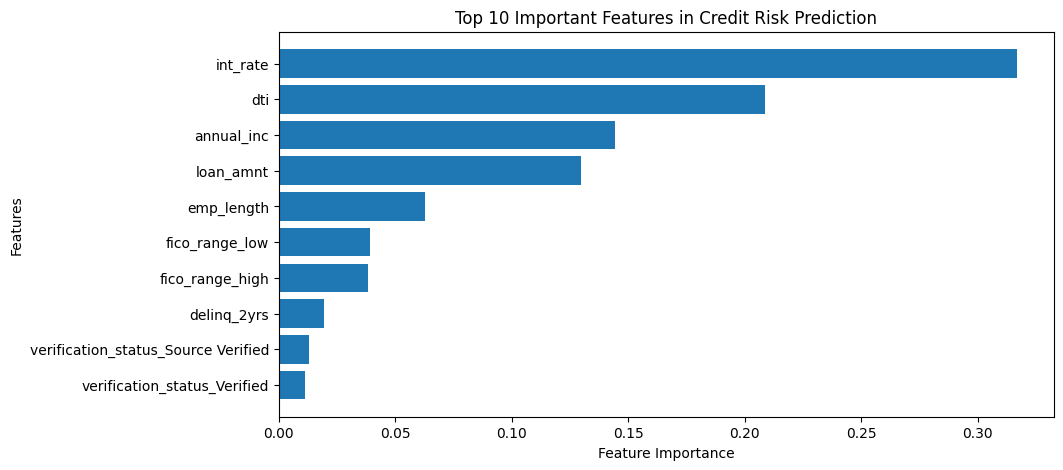

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances
feature_importances = best_dt.feature_importances_
feature_names = X_train.columns

# Sort features by importance
sorted_idx = np.argsort(feature_importances)[::-1]
top_features = feature_names[sorted_idx][:10]  # Show top 10

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.barh(top_features[::-1], feature_importances[sorted_idx][:10][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features in Credit Risk Prediction")
plt.show()


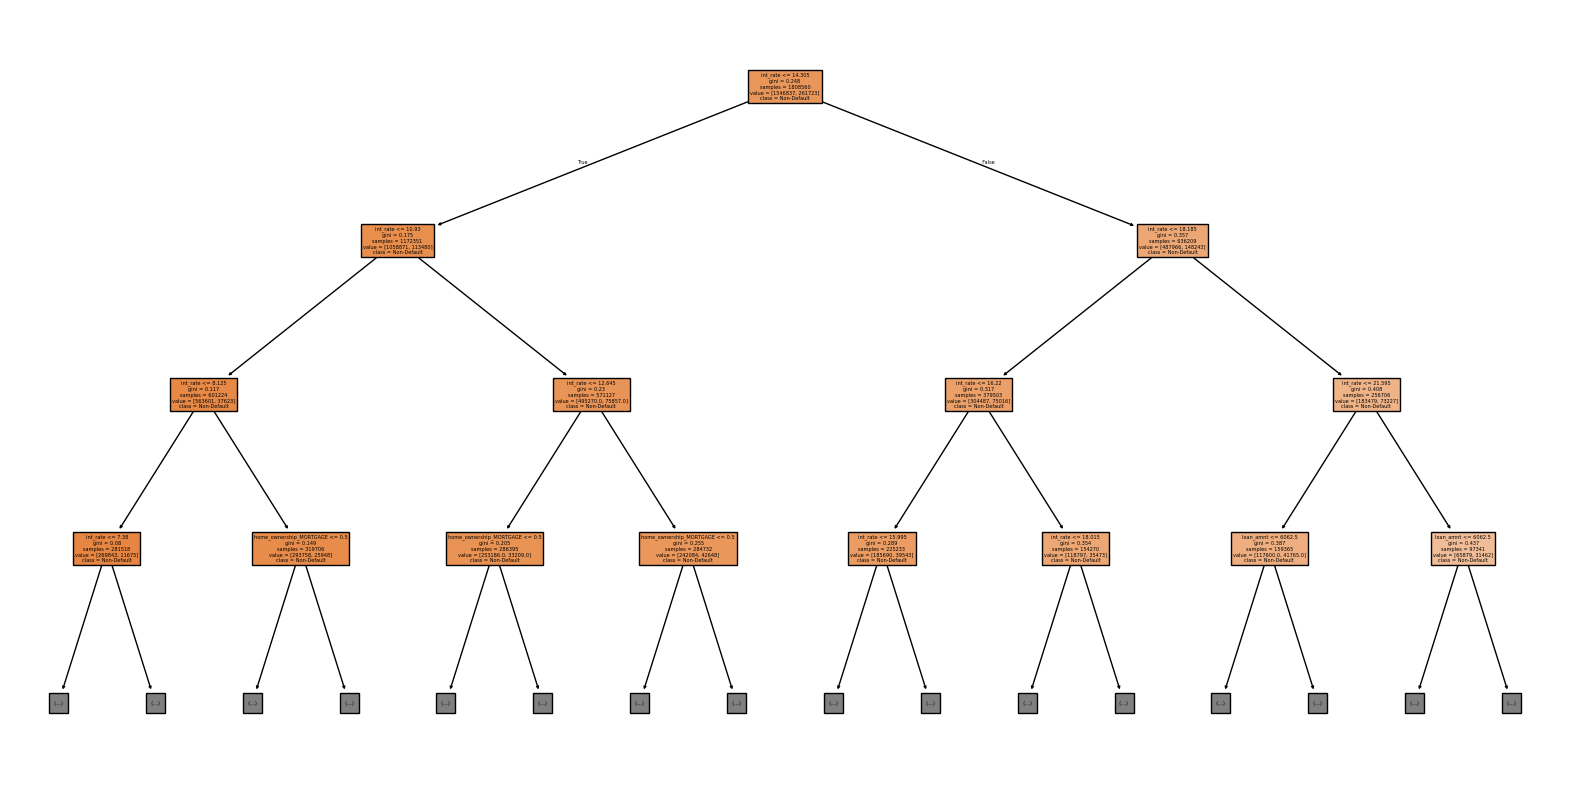

In [47]:
from sklearn.tree import plot_tree

# Visualize the Decision Tree (limited depth for readability)
plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X_train.columns, class_names=["Non-Default", "Default"], filled=True, max_depth=3)
plt.show()


In [48]:
from sklearn.tree import export_text

# Generate text representation of the decision tree
tree_rules = export_text(best_dt, feature_names=list(X_train.columns), max_depth=3)
print(tree_rules)


|--- int_rate <= 14.31
|   |--- int_rate <= 10.93
|   |   |--- int_rate <= 8.12
|   |   |   |--- int_rate <= 7.38
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- int_rate >  7.38
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- int_rate >  8.12
|   |   |   |--- home_ownership_MORTGAGE <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- home_ownership_MORTGAGE >  0.50
|   |   |   |   |--- truncated branch of depth 17
|   |--- int_rate >  10.93
|   |   |--- int_rate <= 12.64
|   |   |   |--- home_ownership_MORTGAGE <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- home_ownership_MORTGAGE >  0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- int_rate >  12.64
|   |   |   |--- home_ownership_MORTGAGE <= 0.50
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- home_ownership_MORTGAGE >  0.50
|   |   |   |   |--- truncated branch of depth 17
|--- int_rate >  14.31
|   |--- int_rat

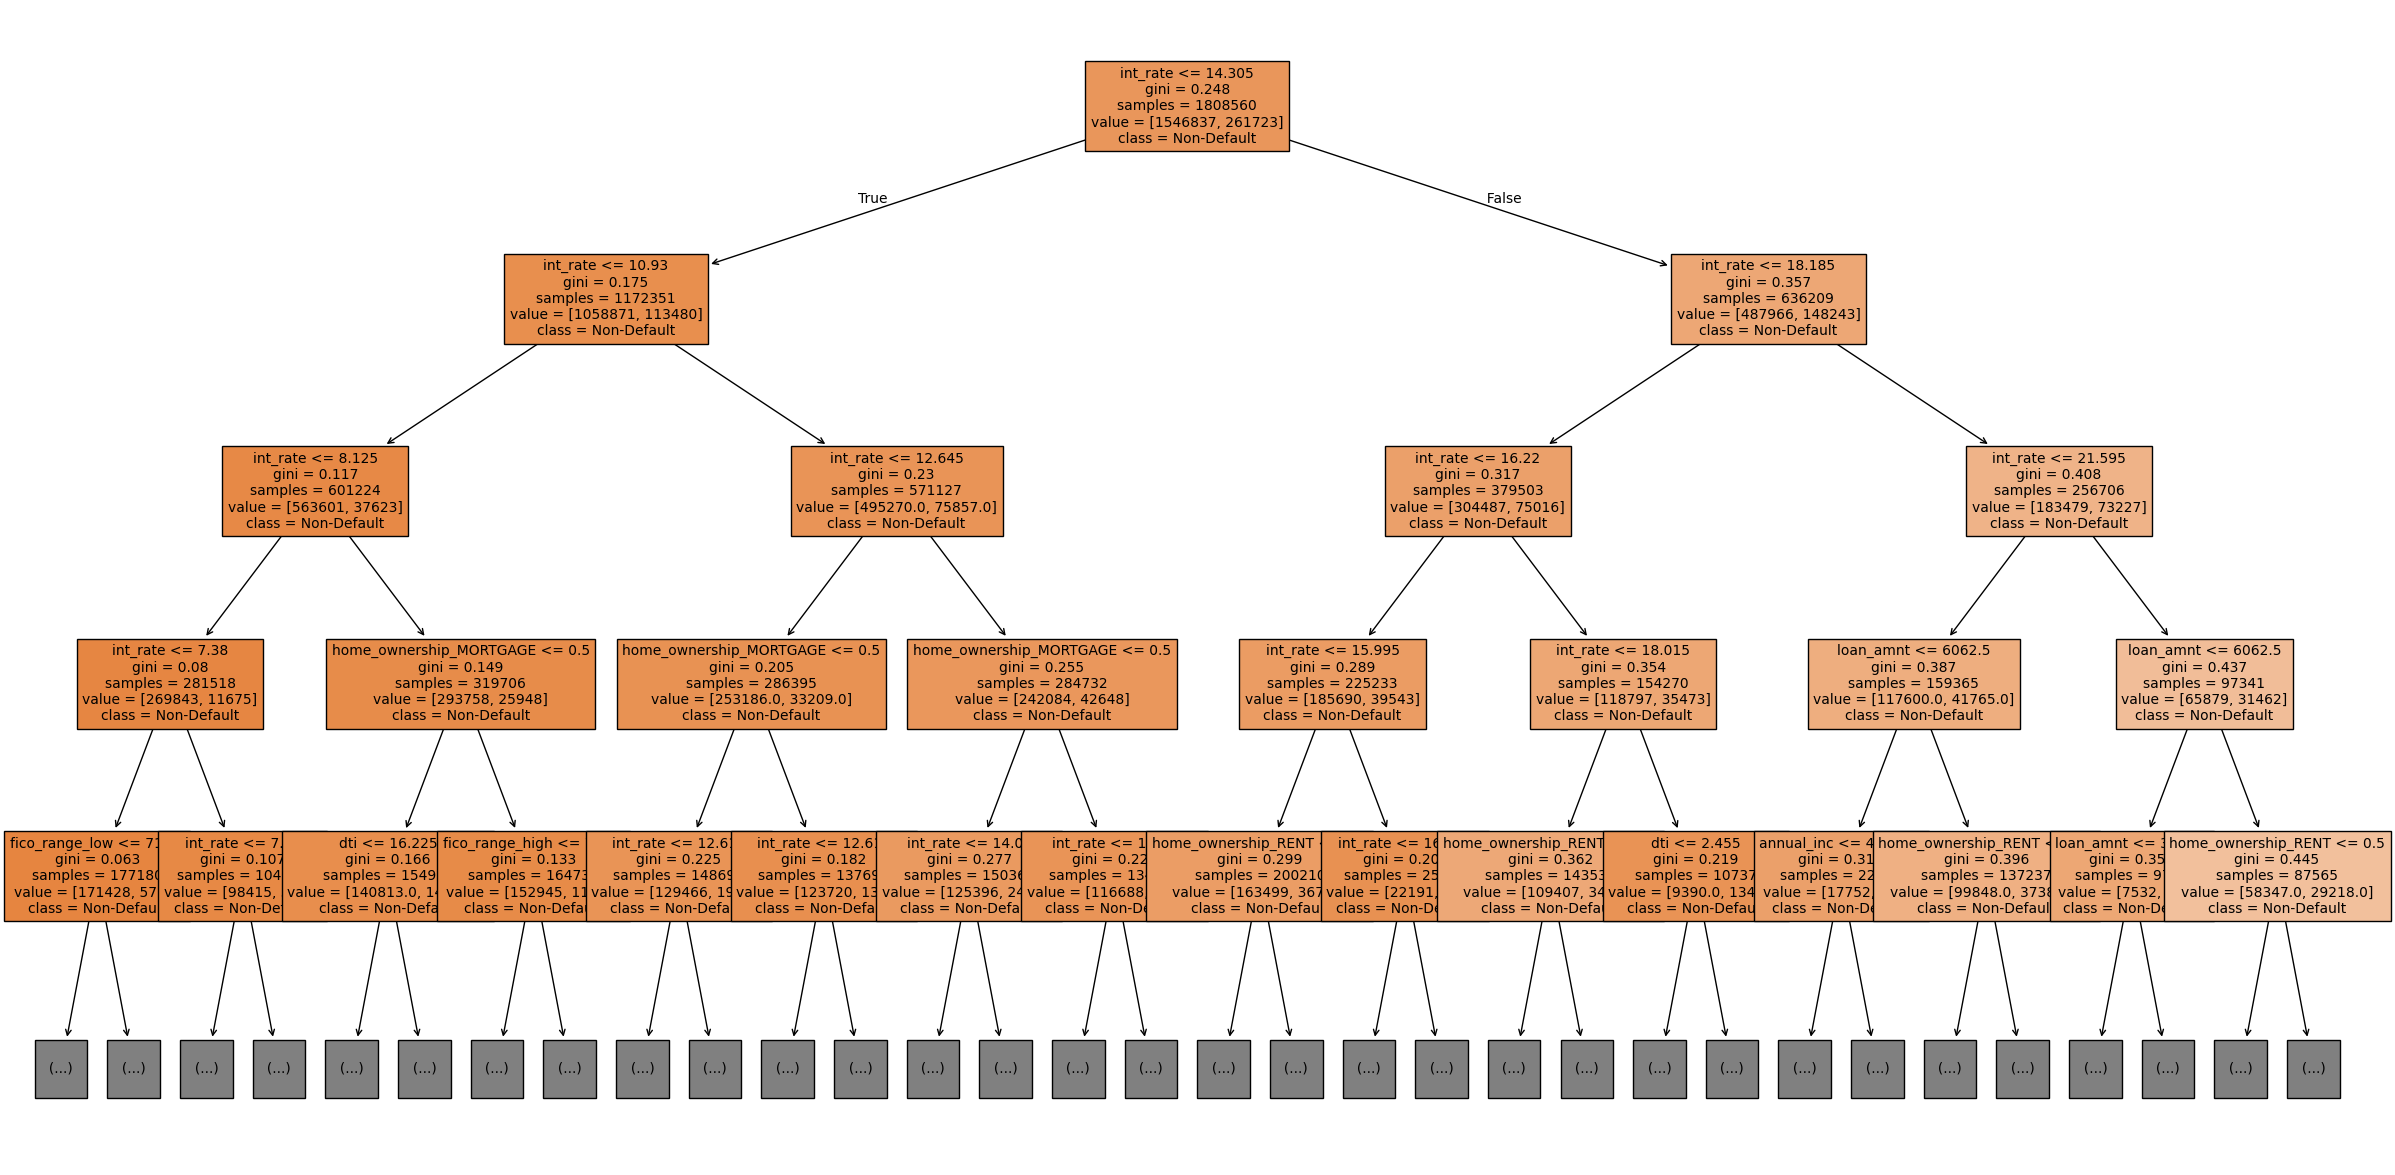

In [49]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a larger, clearer visualization
plt.figure(figsize=(30, 15))  # Increase figure size
plot_tree(best_dt, feature_names=X_train.columns, class_names=["Non-Default", "Default"], filled=True, fontsize=10, max_depth=4)
plt.show()
